In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split    
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import shuffle
from sklearn.model_selection import cross_val_score

In [146]:
df = pd.read_csv('Student_Performance.csv')

In [147]:
df.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


In [148]:
df.tail()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
24995,12047,17,female,public,phd,1.8,55.2,yes,15-30 min,no,mixed,55.8,48.5,46.7,46.1,e
24996,1102,16,female,private,diploma,2.7,97.1,yes,<15 min,no,coaching,64.8,48.2,52.3,56.5,d
24997,4422,19,other,private,post graduate,1.0,63.0,yes,<15 min,no,group study,50.5,20.3,36.1,36.7,f
24998,7858,14,male,private,diploma,1.0,69.4,yes,15-30 min,yes,group study,13.0,34.2,7.3,34.1,f
24999,11621,18,other,public,no formal,0.7,60.3,yes,30-60 min,no,mixed,36.5,45.1,16.5,31.4,f


In [149]:
df.shape

(25000, 16)

In [150]:
df.columns

Index(['student_id', 'age', 'gender', 'school_type', 'parent_education',
       'study_hours', 'attendance_percentage', 'internet_access',
       'travel_time', 'extra_activities', 'study_method', 'math_score',
       'science_score', 'english_score', 'overall_score', 'final_grade'],
      dtype='object')

In [151]:
df.describe()

,student_id,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score
count,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,7493.04380,16.482760,4.253224,75.084084,63.785944,63.745320,63.681948,64.006172
std,4323.56215,1.703895,2.167541,14.373171,20.875262,20.970529,20.792693,18.932025
min,1.00000,14.000000,0.500000,50.000000,0.000000,0.000000,0.000000,14.500000
25%,3743.75000,15.000000,2.400000,62.800000,48.300000,48.200000,48.300000,49.000000
50%,7461.50000,16.000000,4.300000,75.100000,64.100000,64.100000,64.200000,64.200000
75%,11252.00000,18.000000,6.100000,87.500000,80.000000,80.000000,80.000000,79.000000
max,15000.00000,19.000000,8.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  object 
 3   school_type            25000 non-null  object 
 4   parent_education       25000 non-null  object 
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  object 
 8   travel_time            25000 non-null  object 
 9   extra_activities       25000 non-null  object 
 10  study_method           25000 non-null  object 
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_score          25000 non-null  float64
 15  fi

In [153]:
df.drop('student_id', axis=1, inplace=True)

In [154]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

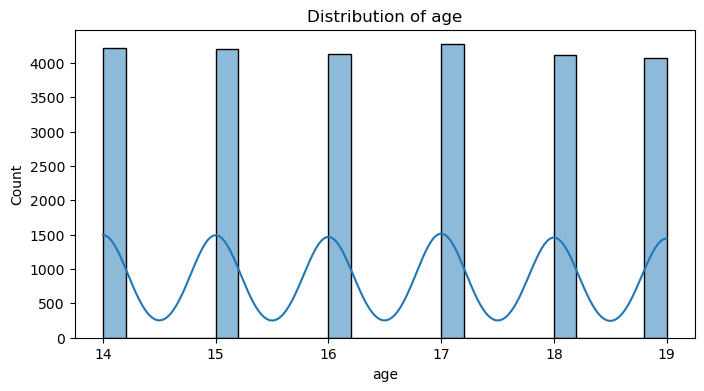

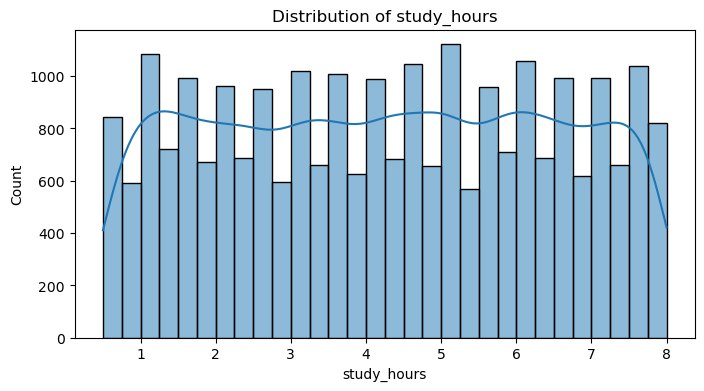

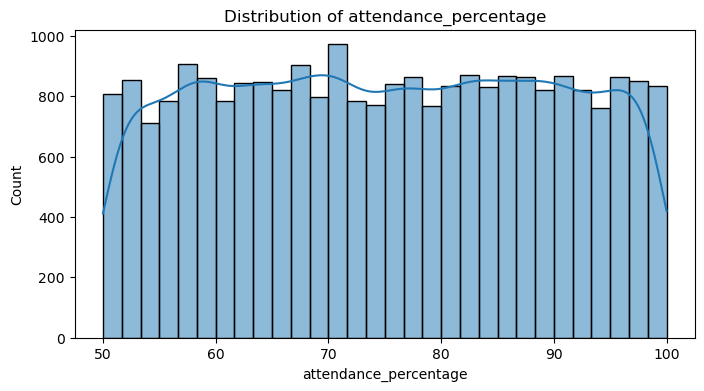

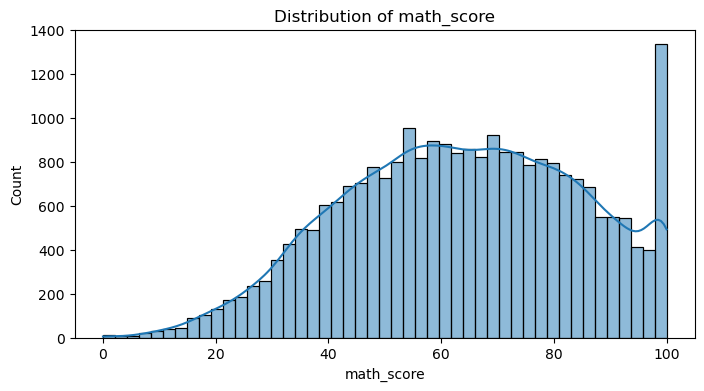

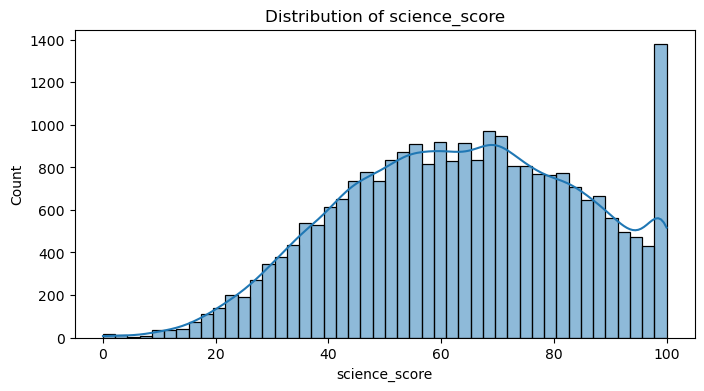

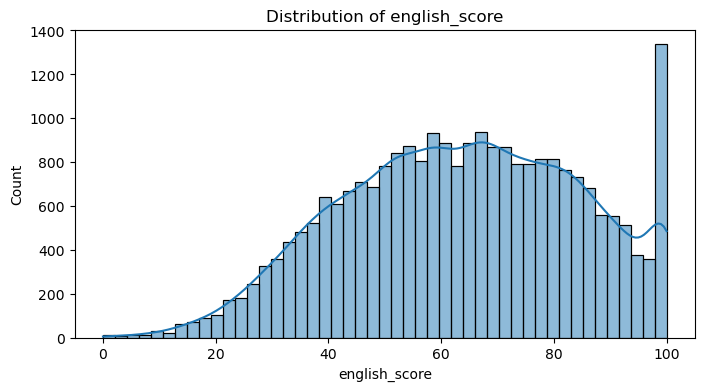

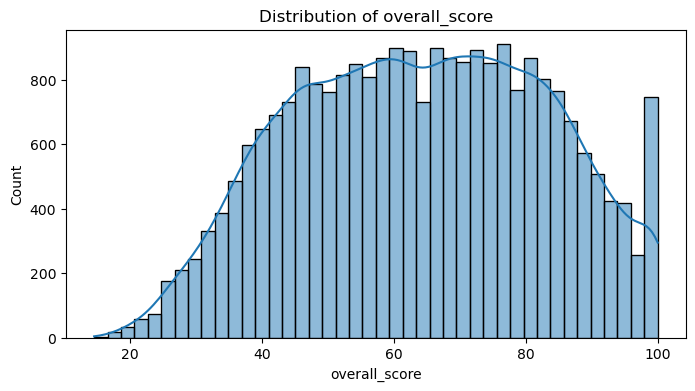

In [155]:
for i in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[i], kde=True)
    plt.title(f'Distribution of {i}')
    plt.show()

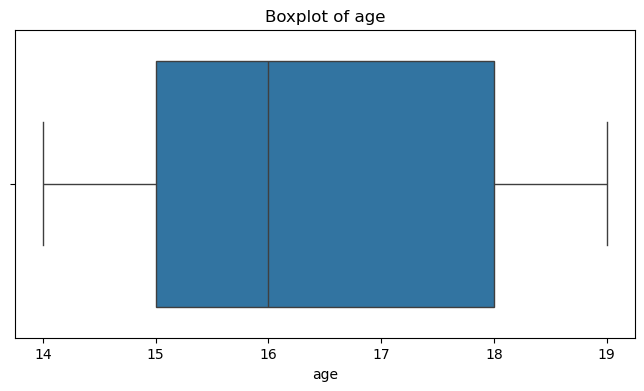

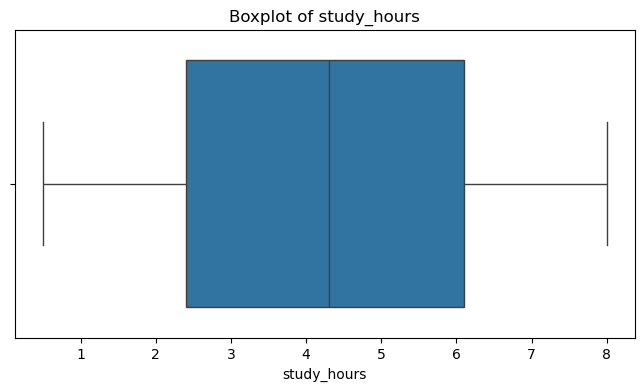

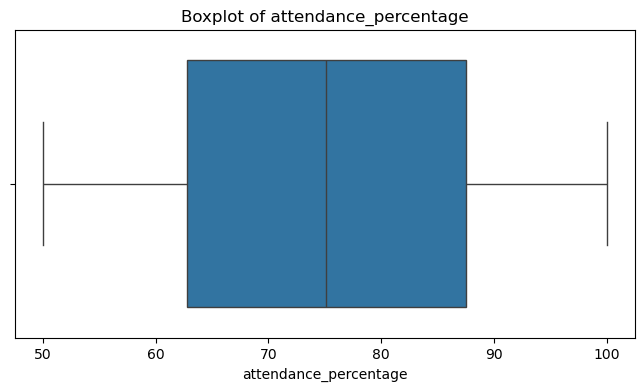

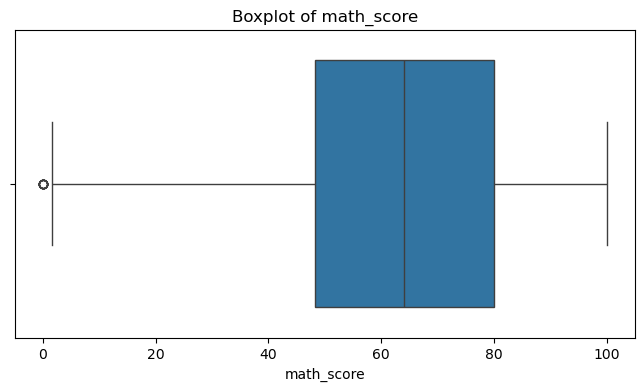

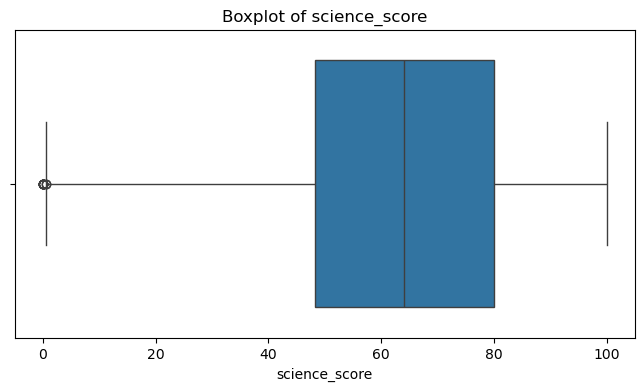

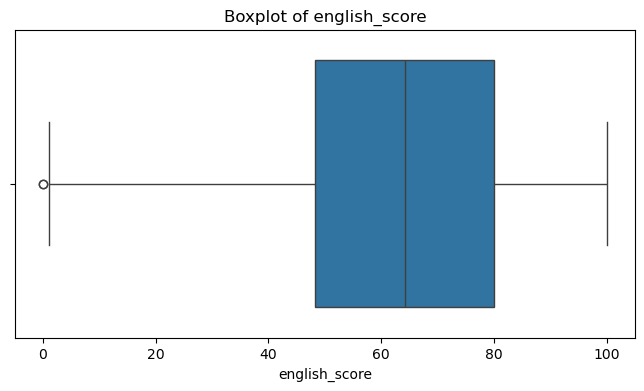

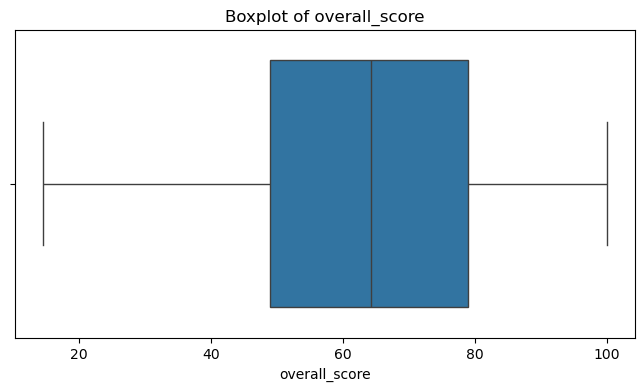

In [156]:
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

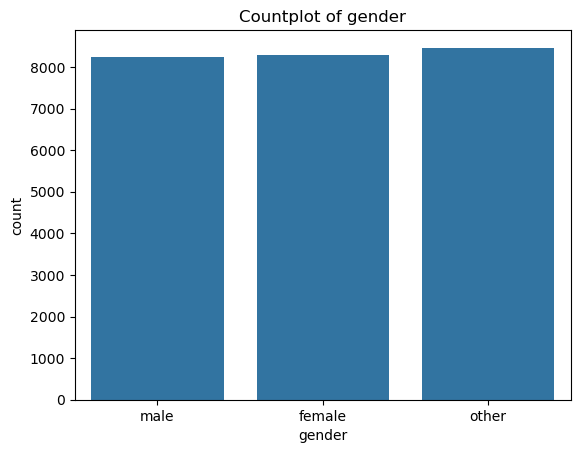

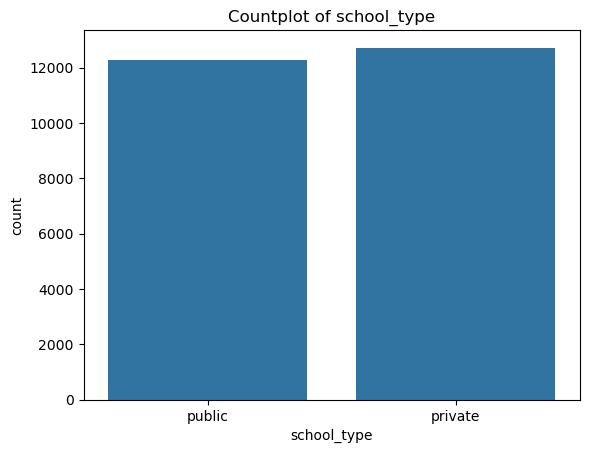

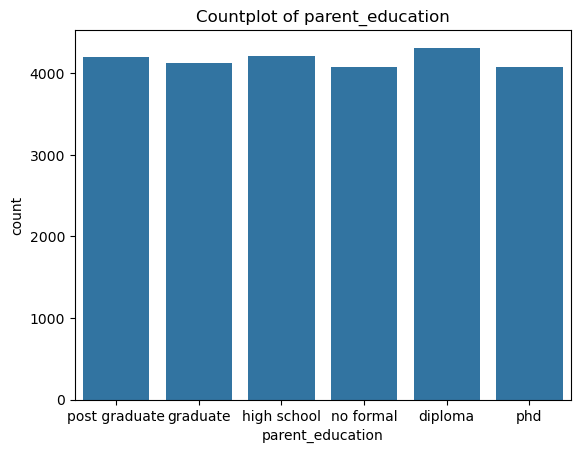

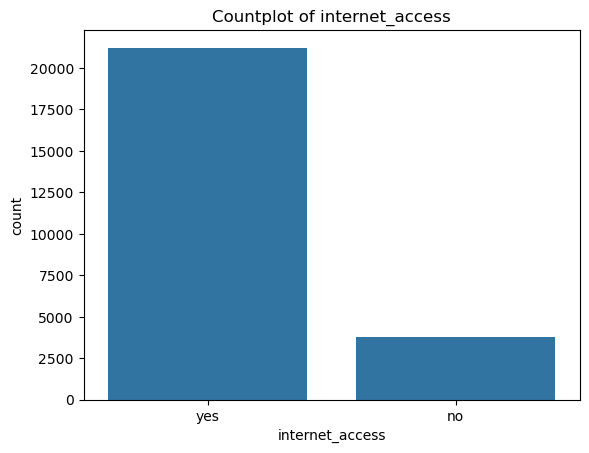

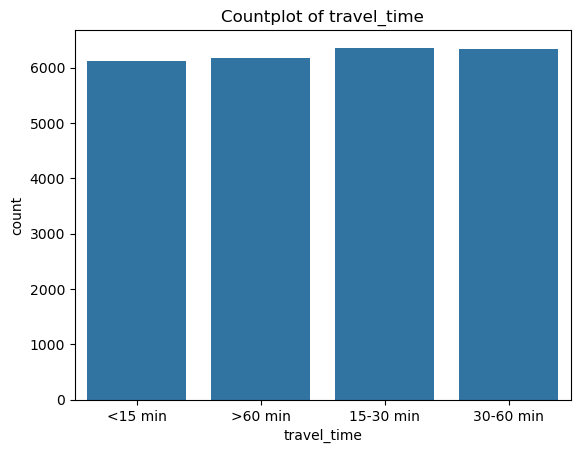

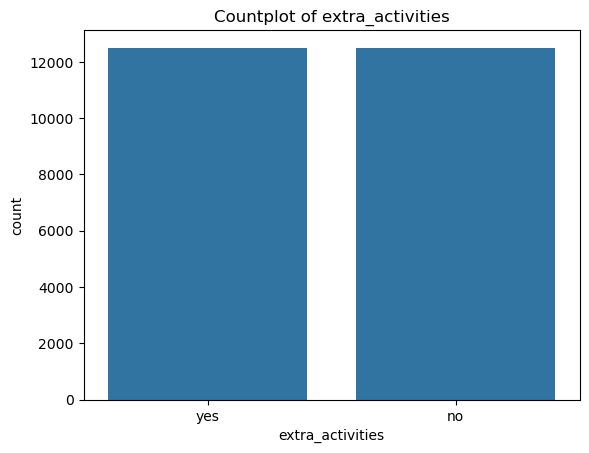

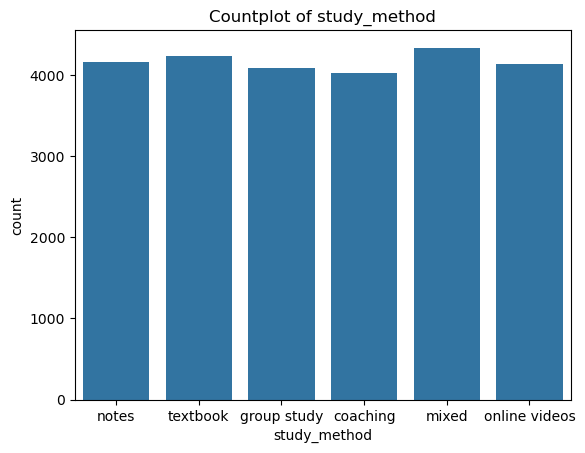

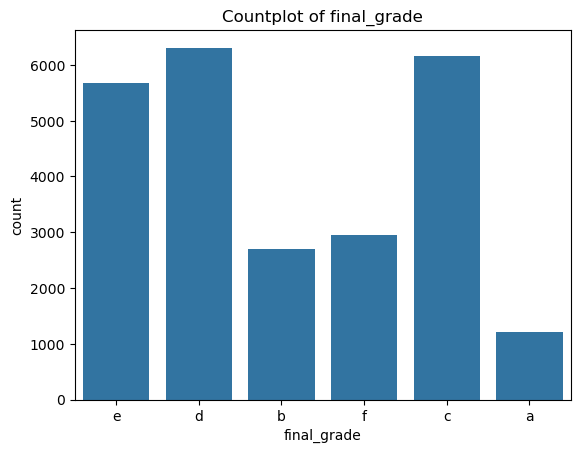

In [157]:
for col in categorical_cols:
    sns.countplot(x=df[col])
    plt.title(f'Countplot of {col}')
    plt.show()

In [158]:
df.isnull().sum()

age                      0
gender                   0
school_type              0
parent_education         0
study_hours              0
attendance_percentage    0
internet_access          0
travel_time              0
extra_activities         0
study_method             0
math_score               0
science_score            0
english_score            0
overall_score            0
final_grade              0
dtype: int64

In [159]:
df.isnull().sum().sum()

0

In [160]:
df.duplicated().sum()

10000

In [161]:
df.drop_duplicates(inplace=True)

In [162]:
df.duplicated().sum()

0

In [163]:
df.shape

(15000, 15)

In [164]:
df.corr(numeric_only=True)

,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score
age,1.000000,0.004240,0.004521,0.000575,0.008525,0.002694,0.004981
study_hours,0.004240,1.000000,-0.009486,0.802971,0.804551,0.804208,0.905885
attendance_percentage,0.004521,-0.009486,1.000000,0.252210,0.248960,0.253859,0.288473
math_score,0.000575,0.802971,0.252210,1.000000,0.785904,0.788176,0.885394
science_score,0.008525,0.804551,0.248960,0.785904,1.000000,0.785256,0.886058
english_score,0.002694,0.804208,0.253859,0.788176,0.785256,1.000000,0.884869
overall_score,0.004981,0.905885,0.288473,0.885394,0.886058,0.884869,1.000000


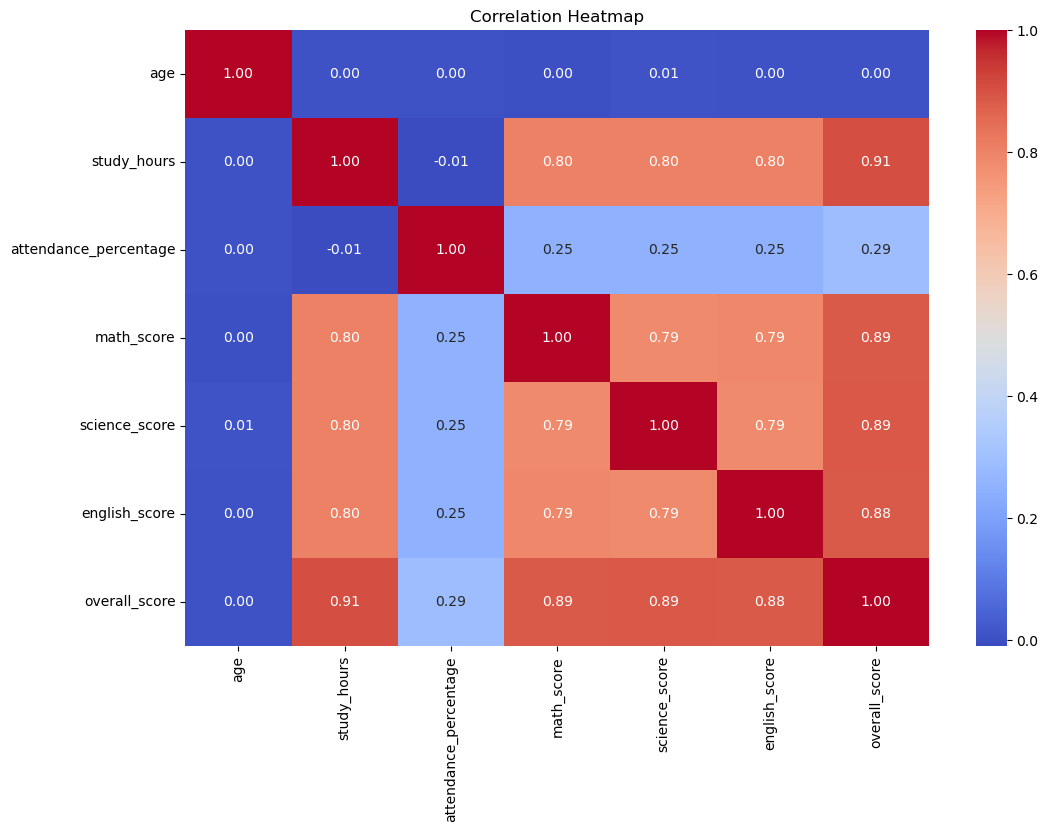

In [165]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [166]:
X = df.drop(columns=["final_grade", "overall_score"])
y = df["final_grade"]

In [167]:
cat_cols = categorical_cols.drop('final_grade')
num_cols = numerical_cols.drop(['overall_score'])

In [168]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [169]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)  
    ])

In [170]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [171]:
preprocessor.get_feature_names_out()

array(['num__age', 'num__study_hours', 'num__attendance_percentage',
       'num__math_score', 'num__science_score', 'num__english_score',
       'cat__gender_male', 'cat__gender_other', 'cat__school_type_public',
       'cat__parent_education_graduate',
       'cat__parent_education_high school',
       'cat__parent_education_no formal', 'cat__parent_education_phd',
       'cat__parent_education_post graduate', 'cat__internet_access_yes',
       'cat__travel_time_30-60 min', 'cat__travel_time_<15 min',
       'cat__travel_time_>60 min', 'cat__extra_activities_yes',
       'cat__study_method_group study', 'cat__study_method_mixed',
       'cat__study_method_notes', 'cat__study_method_online videos',
       'cat__study_method_textbook'], dtype=object)

In [172]:
X_train_df = pd.DataFrame(X_train_processed, columns=preprocessor.get_feature_names_out())
X_test_df = pd.DataFrame(X_test_processed, columns=preprocessor.get_feature_names_out())

In [173]:
X_train_df.head()

,num__age,num__study_hours,num__attendance_percentage,num__math_score,num__science_score,num__english_score,cat__gender_male,cat__gender_other,cat__school_type_public,cat__parent_education_graduate,...,cat__internet_access_yes,cat__travel_time_30-60 min,cat__travel_time_<15 min,cat__travel_time_>60 min,cat__extra_activities_yes,cat__study_method_group study,cat__study_method_mixed,cat__study_method_notes,cat__study_method_online videos,cat__study_method_textbook
0,-0.277408,-1.224581,-0.110828,-0.231457,-0.288624,-0.515428,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-1.448727,1.536420,1.009645,1.728829,1.086107,1.746376,0.0,1.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-0.277408,-1.592714,-1.008598,-2.062336,-1.143058,-1.083285,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.308252,0.892187,-0.820693,0.012980,0.207806,0.370044,0.0,1.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-1.448727,1.490404,1.030523,1.321435,1.200668,1.221830,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0


In [174]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_df, y_train)
y_pred = rf_classifier.predict(X_test_df)

In [175]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[ 90  63   2   0   0   0]
 [ 17 215  82   0   0   0]
 [  0  61 590 101   0   0]
 [  0   0  79 567  75   0]
 [  0   0   0  92 523  55]
 [  0   0   0   0 102 286]]

Classification Report:
              precision    recall  f1-score   support

           a       0.84      0.58      0.69       155
           b       0.63      0.68      0.66       314
           c       0.78      0.78      0.78       752
           d       0.75      0.79      0.77       721
           e       0.75      0.78      0.76       670
           f       0.84      0.74      0.78       388

    accuracy                           0.76      3000
   macro avg       0.77      0.73      0.74      3000
weighted avg       0.76      0.76      0.76      3000



In [176]:
print("TRAIN")
print(classification_report(y_train, rf_classifier.predict(X_train_df)))

print("TEST")
print(classification_report(y_test, rf_classifier.predict(X_test_df)))

TRAIN
              precision    recall  f1-score   support

           a       1.00      1.00      1.00       566
           b       1.00      1.00      1.00      1324
           c       1.00      1.00      1.00      2945
           d       1.00      1.00      1.00      3049
           e       1.00      1.00      1.00      2708
           f       1.00      1.00      1.00      1408

    accuracy                           1.00     12000
   macro avg       1.00      1.00      1.00     12000
weighted avg       1.00      1.00      1.00     12000

TEST
              precision    recall  f1-score   support

           a       0.84      0.58      0.69       155
           b       0.63      0.68      0.66       314
           c       0.78      0.78      0.78       752
           d       0.75      0.79      0.77       721
           e       0.75      0.78      0.76       670
           f       0.84      0.74      0.78       388

    accuracy                           0.76      3000
   macro avg

In [177]:
scores = cross_val_score(rf_classifier, X_train_df, y_train, cv=5, scoring="f1_weighted")
print(scores)
print("Mean:", scores.mean())


[0.74455222 0.75949729 0.73935511 0.75753621 0.76080659]
Mean: 0.7523494824808187


In [178]:
X_train_shuf, y_train_shuf = shuffle(
    X_train_df,
    y_train,
    random_state=42
)

scores = cross_val_score(
    rf_classifier,
    X_train_shuf,
    y_train_shuf,
    cv=5,
    scoring="accuracy"
)

print("Mean shuffled CV score:", scores.mean())


Mean shuffled CV score: 0.75125
